# **Heart Disease** | Timer 1
---

**Kata-kata hari ini:**

- Tak perlu kata-kata, yang penting bukti nyata - *laufie*

# **I. Data Understanding**

## ***A. Penjabaran Studi Kasus***

Penyakit jantung merupakan penyakit fatal yang bisa menjangkit siapa saja, tidak pandang usia, gender, maupun warna kulit.

Pada kesempatan kali ini, kami diberikan suatu dataset dari pihak rumah sakit yang berisikan data pasien setelah di tes indikasi penyakit jantung. Kami diminta untuk membuat model klasifikasi, dengan tujuan memprediksi jika pasien akan terjangkit penyakit jantung atau tidak, agar dokter dapat bertindak lebih cepat sebelum kondisi pasien menjadi parah. Kami berharap bisa memberikan insight sehingga dapat mengetahui apa saja yang bisa mempengaruhi kondisi seseorang sehingga ia dapat terjangkit penyakit jantung, dan tentunya membuat model optimal dengan hasil prediksi yang tepat dan akurat.

## ***B. Import Libraries***

In [345]:
import pandas as pd
import numpy as np
import seaborn as sns
import  matplotlib.pyplot as plt

## ***C. Import Dataset***

In [346]:
dataset = pd.read_csv("heart.csv")

In [347]:
dataset

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


# **II. Data Preparation**

## ***A. Exploratory Data Analysis***

### 1. Inspeksi Daftar Variabel

In [348]:
dataset.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

Kami menganalisa makna setiap fitur dan karakteristik value setiap fitur, kami berhasil mengidentifikasi tipe data setiap fitur

Numerik Continu: `RestingBP`, `Cholestrol`, `FastingBS`

Numerik Diskrit: `Age`, `MaxHR`, `Oldpeak`

Kategorikal Ordinal: `ChestPainType`, `RestingECG`, `ExerciseAngina`, `ST_slope`

Kategorikal Nominal: `Sex`

In [349]:
sedanten_fitur = ['Age','Sex','ChestPainType','RestingBP','Cholesterol','FastingBS','RestingECG','MaxHR','ExerciseAngina','Oldpeak','ST_Slope']
fitur_continu = ['RestingBP', 'Cholesterol', 'FastingBS', 'HeartDisease']
fitur_diskrit = ['Age', 'MaxHR', 'Oldpeak',  'HeartDisease']
fitur_ordinal = ['ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope',  'HeartDisease']
fitur_nominal = ['Sex']

### 2. Inspeksi Informasi Ringkas

In [350]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


### 3. Inspeksi Statistik Deskriptif

In [351]:
dataset.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [352]:
dataset[['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']].var()

Age               88.974254
RestingBP        342.773903
Cholesterol    11964.891079
FastingBS          0.178968
MaxHR            648.228614
Oldpeak            1.137572
dtype: float64

### 4. Inspeksi Data NaN

In [353]:
dataset.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

### 5. Inspeksi Data Duplicated

In [354]:
dataset.duplicated().sum()

np.int64(0)

### 6. Univariate Analysis

#### *a. Inspeksi Distribusi Kelas Target*

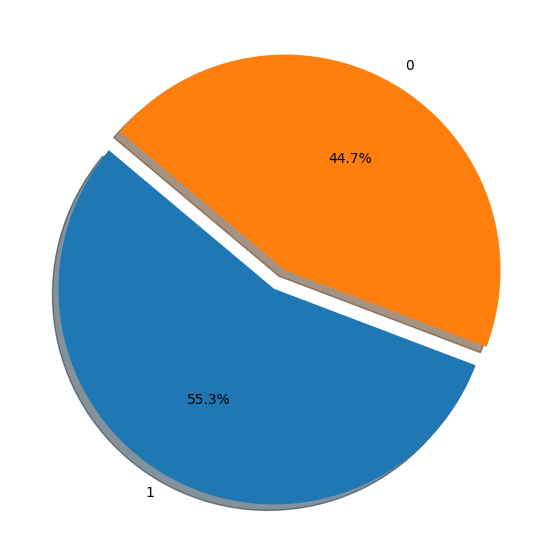

In [355]:
plt.figure(figsize = (7,7))
target_count = dataset['HeartDisease'].value_counts()
explode = [0.05] * len(target_count)

plt.pie(
    target_count,
    labels = target_count.index,
    autopct = "%1.1f%%",
    explode = explode,
    startangle = 140,
    shadow = True
)
plt.show()

#### b. Inspeksi Distribusi Kelas Fitur

In [356]:
def check_value(dataset, col):
    for cols in col:
        print("=" * 40)
        print(f"Kolom: {cols}")
        print("=" * 40)
        print(dataset[cols].value_counts())
        print('\n')

Ordinal

In [357]:
check_value(dataset, fitur_ordinal)

Kolom: ChestPainType
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64


Kolom: RestingECG
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64


Kolom: ExerciseAngina
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64


Kolom: ST_Slope
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64


Kolom: HeartDisease
HeartDisease
1    508
0    410
Name: count, dtype: int64




Nominal

In [358]:
check_value(dataset, fitur_nominal)

Kolom: Sex
Sex
M    725
F    193
Name: count, dtype: int64




Ordinal

In [359]:
check_value(dataset, fitur_ordinal)

Kolom: ChestPainType
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64


Kolom: RestingECG
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64


Kolom: ExerciseAngina
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64


Kolom: ST_Slope
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64


Kolom: HeartDisease
HeartDisease
1    508
0    410
Name: count, dtype: int64




### 7. Bivariate Analysis

#### a. Inspeksi Distribusi Fitur dengan Target

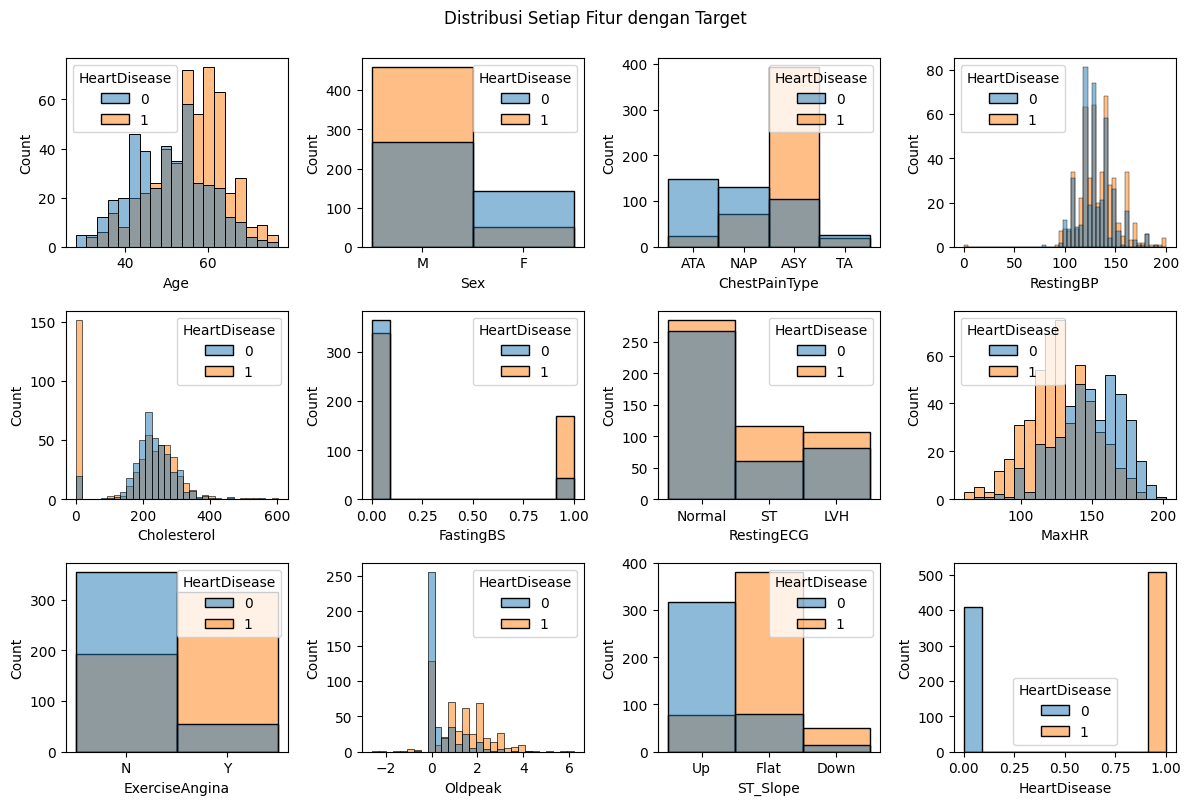

In [360]:
plt.figure(figsize=(12, 8))

for i, col in enumerate(dataset):
    plt.subplot(3, 4, i+1)
    sns.histplot(x=dataset[col], hue=dataset["HeartDisease"])

plt.suptitle("Distribusi Setiap Fitur dengan Target", y=1.001)
plt.tight_layout()
plt.show()

### 8. Multivariate Analysis

#### *a. Inspeksi Distribusi Data dengan Target*

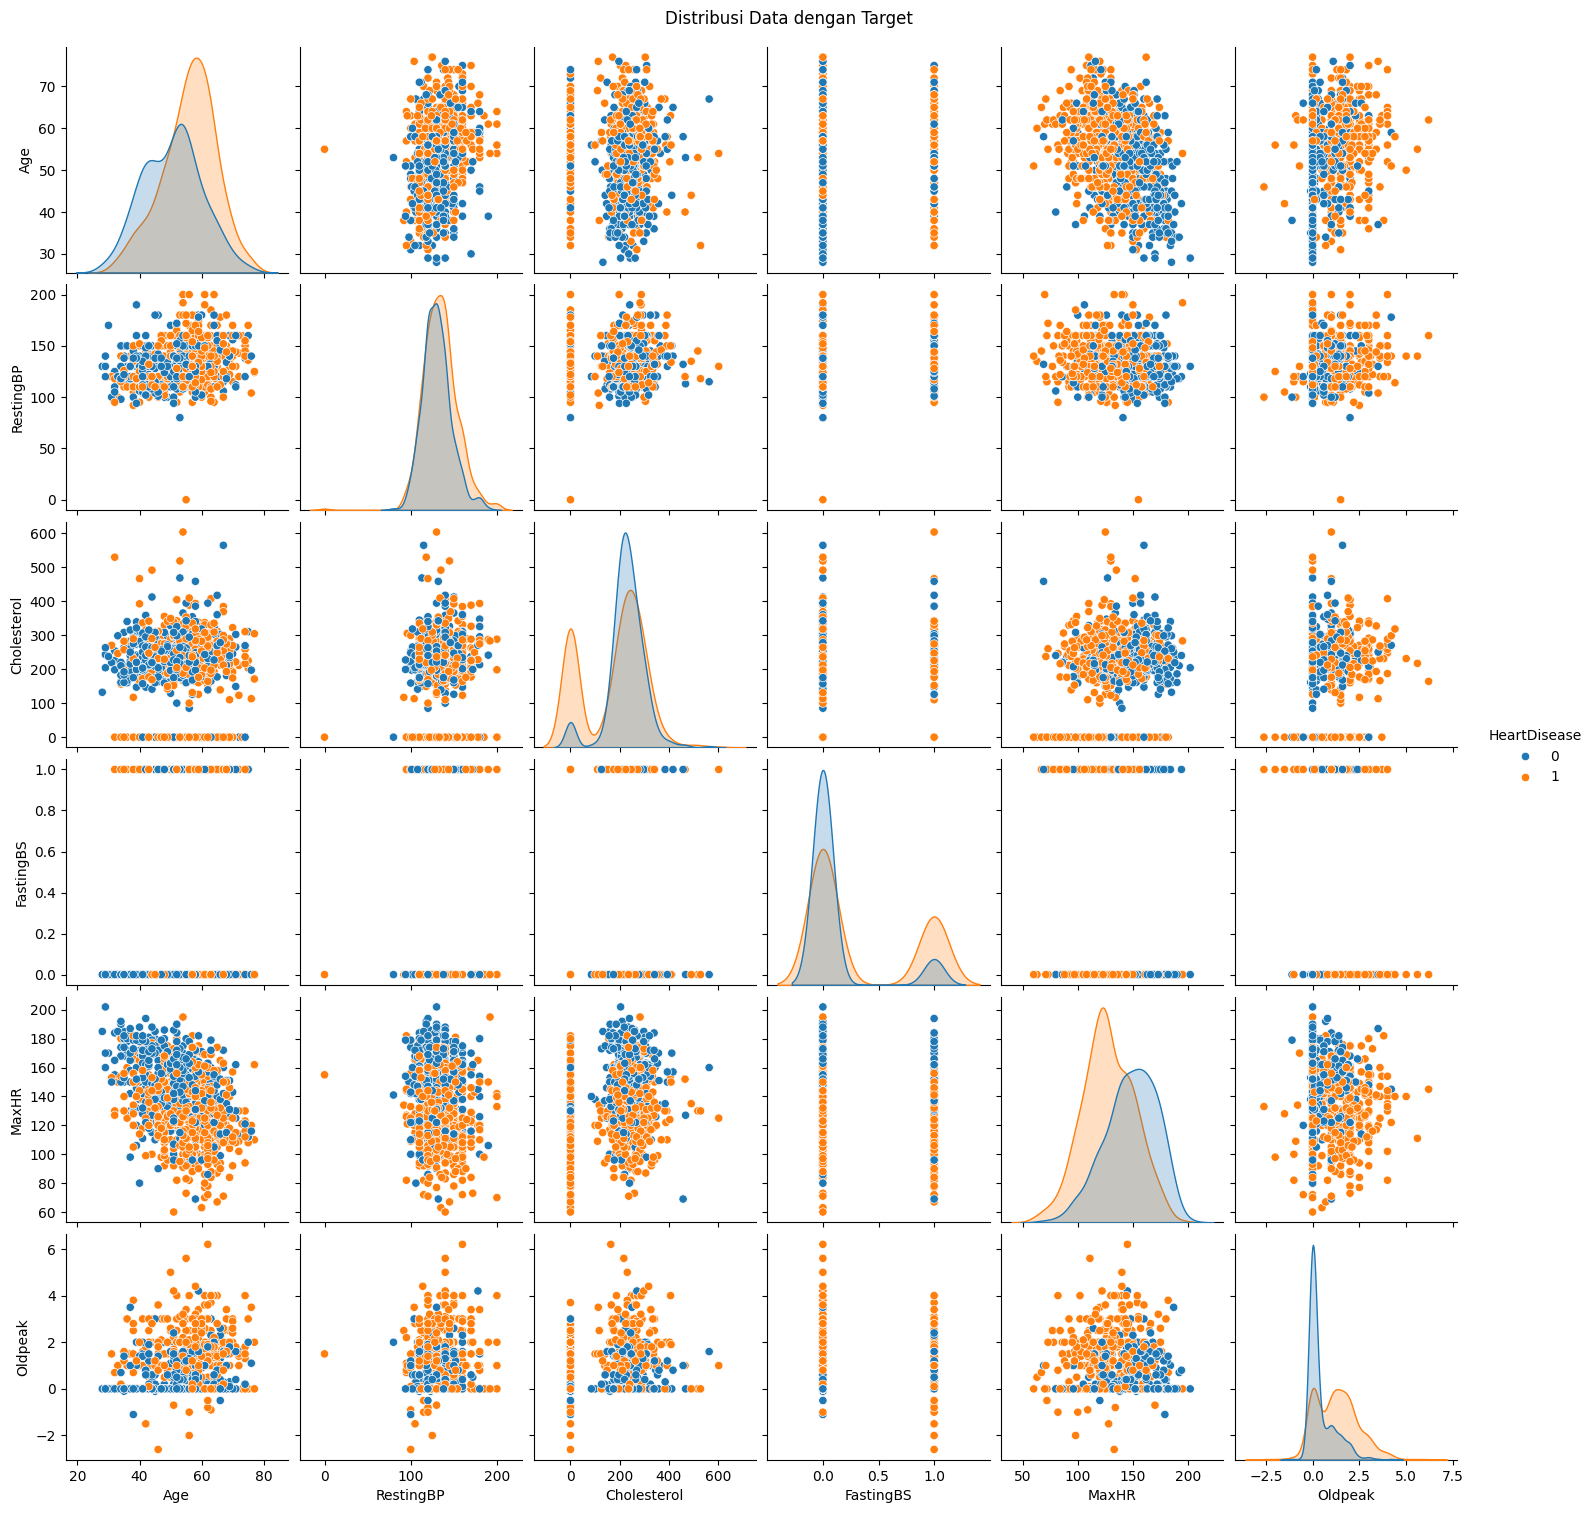

In [361]:
sns.pairplot(data=dataset, hue="HeartDisease")
plt.suptitle("Distribusi Data dengan Target", y=1.01)
plt.show()

### 9. Dataset Sementara

#### *a. Copy Master*

In [362]:
dataset_copy = dataset.copy()

### *b. Data Preprocessing*

- Encode Fitur Nominal

In [363]:
def label_encode(dataset, col):
    for cols in col:
        dataset[cols] = pd.factorize(dataset[cols])[0]
    
    return dataset

dataset_copy = label_encode(dataset_copy, fitur_nominal)

- Encode Ordinal

In [364]:
map_chest = {'ASY' : 4, 'NAP' : 1, 'ATA' : 2, 'TA' : 3}
map_resting = {'Normal' : 1, 'LVH' : 2, 'ST' : 3}
map_exercise = {'N' : 1, 'Y' : 1}
map_slope = {'Flat' : 1, 'Up' : 3, 'Down' : 2}

dataset_copy['ChestPainType'] = dataset_copy['ChestPainType'].map(map_chest)
dataset_copy['RestingECG'] = dataset_copy['RestingECG'].map(map_resting)
dataset_copy['ExerciseAngina'] = dataset_copy['ExerciseAngina'].map(map_exercise)
dataset_copy['ST_Slope'] = dataset_copy['ST_Slope'].map(map_slope)

### *c. Inspeksi Ulang*

In [365]:
dataset_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    int64  
 2   ChestPainType   918 non-null    int64  
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    int64  
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    int64  
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    int64  
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(11)
memory usage: 86.2 KB


### 10. Inspeksi Korelasi

#### *a. Mutual Information*

In [366]:
def probability_distribution(x):
    unique, counts = np.unique(x, return_counts=True)
    return counts / counts.sum()

def calculate_entropy(x):
    probs = probability_distribution(x)
    return -np.sum(probs * np.log2(probs + 1e-10))

def mutual_information(x, y):
    xy_pairs = list(zip(x, y))
    unique_xy, counts_xy = np.unique(xy_pairs, return_counts=True)
    probs_xy = counts_xy / counts_xy.sum()
    entropy_xy = -np.sum(probs_xy * np.log2(probs_xy + 1e-10))

    entropy_x = calculate_entropy(x)
    entropy_y = calculate_entropy(y)
    return entropy_x + entropy_y - entropy_xy

In [367]:
fitur = dataset_copy[sedanten_fitur]
target = dataset_copy["HeartDisease"]

In [368]:
mi_scores = {col: mutual_information(fitur[col].values, target.values) for col in fitur.columns}
mi_df = pd.DataFrame(list(mi_scores.items()), columns=["Feature", "Mutual Information"])
mi_df = mi_df.sort_values(by="Mutual Information", ascending=False)
mi_df

,Feature,Mutual Information
4,Cholesterol,3.148853
7,MaxHR,2.668353
0,Age,2.108681
9,Oldpeak,1.962988
3,RestingBP,1.850483
5,FastingBS,0.808304
1,Sex,0.774395
6,RestingECG,0.756835
10,ST_Slope,0.666313
2,ChestPainType,0.645745


C:\Users\ACER\AppData\Local\Temp\ipykernel_7032\1408996391.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mi_df, x="Feature", y="Mutual Information", palette="magma")


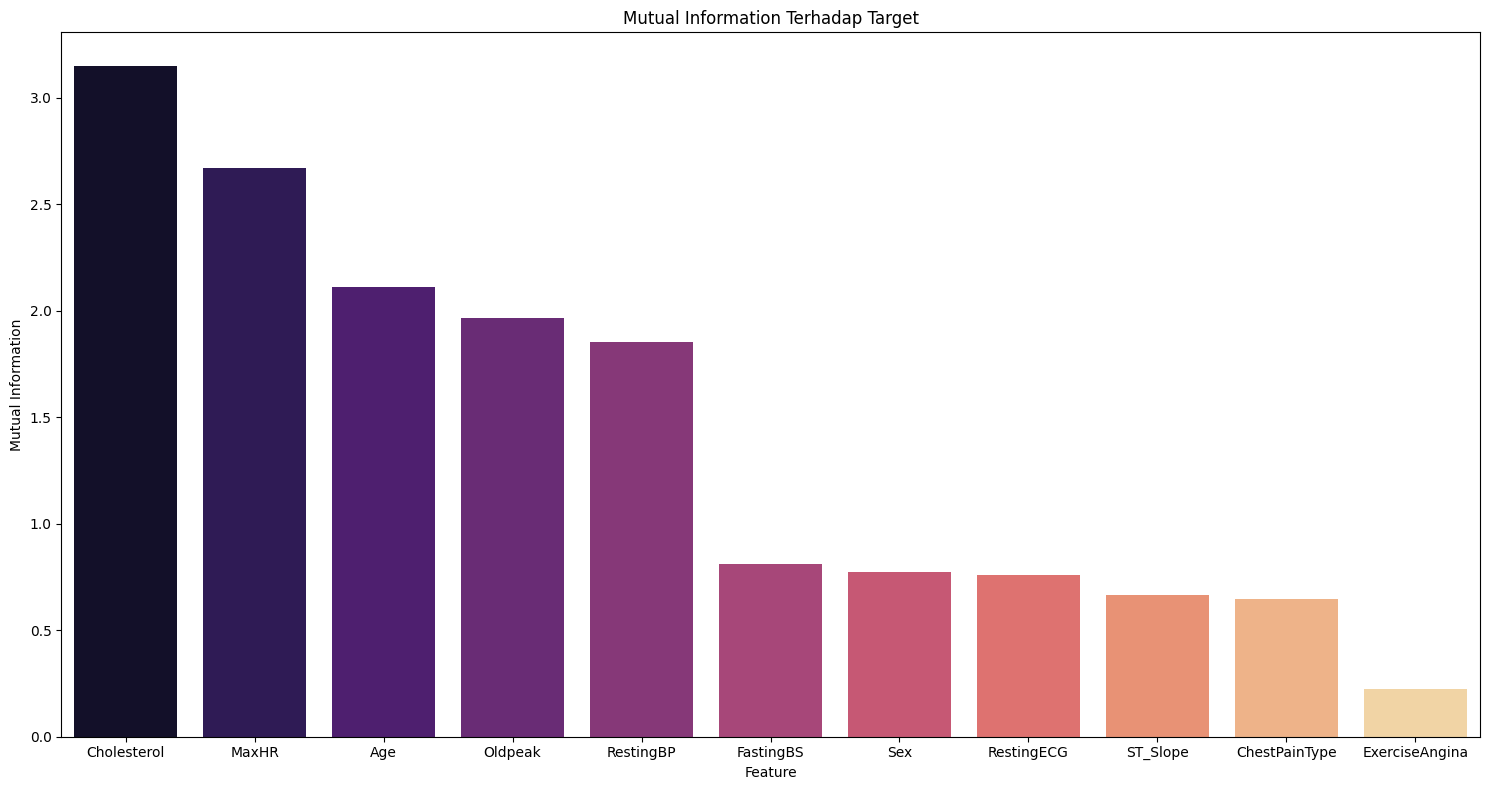

In [369]:
plt.figure(figsize=(15, 8))
sns.barplot(data=mi_df, x="Feature", y="Mutual Information", palette="magma")

plt.title("Mutual Information Terhadap Target")
plt.xlabel("Feature")
plt.ylabel("Mutual Information")
plt.tight_layout()
plt.show()

#### *b. Kendall Method*

In [370]:
def kendall_method(x, y):

    n = len(x)
    concordant = 0
    disconcordant = 0

    for i in range(n - 1):
        for j in range(i + 1, n):

            x_diff = x[i] - x[j]
            y_diff = y[i] - y[j]

            if x_diff * y_diff > 0:
                concordant += 1
            elif x_diff * y_diff < 0:
                disconcordant += 1
    
    if (concordant - disconcordant) == 0:
        return 0
    
    return (concordant - disconcordant) / (concordant + disconcordant)

Fitur Continu

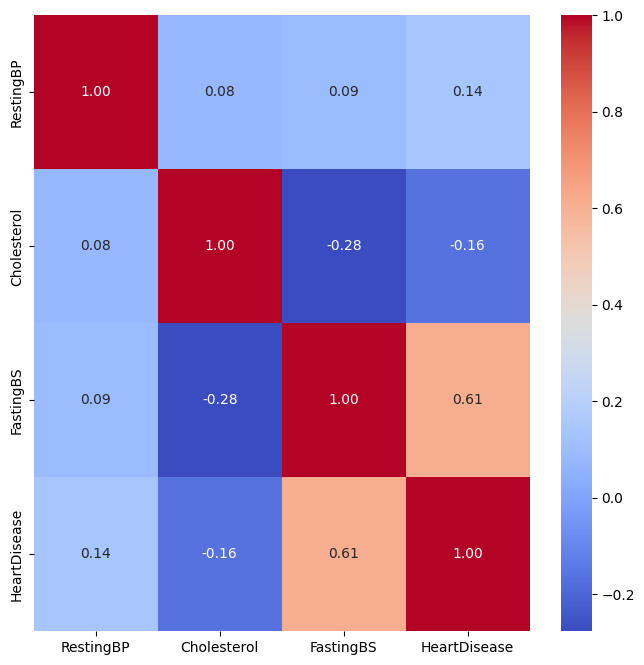

In [371]:
kendall_continu = pd.DataFrame(index = fitur_continu, columns = fitur_continu)

for col1 in fitur_continu:
    for col2 in fitur_continu:
        kendall_continu.loc[col1, col2] = kendall_method(dataset_copy[col1].values, dataset_copy[col2].values)

kendall_continu = kendall_continu.astype(float) 
plt.figure(figsize = (8, 8))
sns.heatmap(kendall_continu, cmap = 'coolwarm', fmt = '.2f', annot = True)
plt.show()

Fitur Diskrit

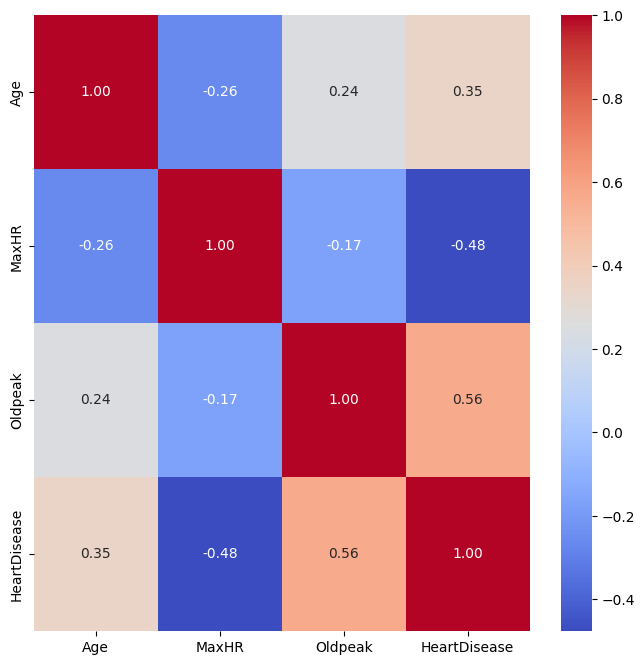

In [372]:
kendall_diskrit = pd.DataFrame(index = fitur_diskrit, columns = fitur_diskrit)

for col1 in fitur_diskrit:
    for col2 in fitur_diskrit:
        kendall_diskrit.loc[col1, col2] = kendall_method(dataset_copy[col1].values, dataset_copy[col2].values)

kendall_diskrit = kendall_diskrit.astype(float) 
plt.figure(figsize = (8, 8))
sns.heatmap(kendall_diskrit, cmap = 'coolwarm', fmt = '.2f', annot = True)
plt.show()

Fitur Ordinal

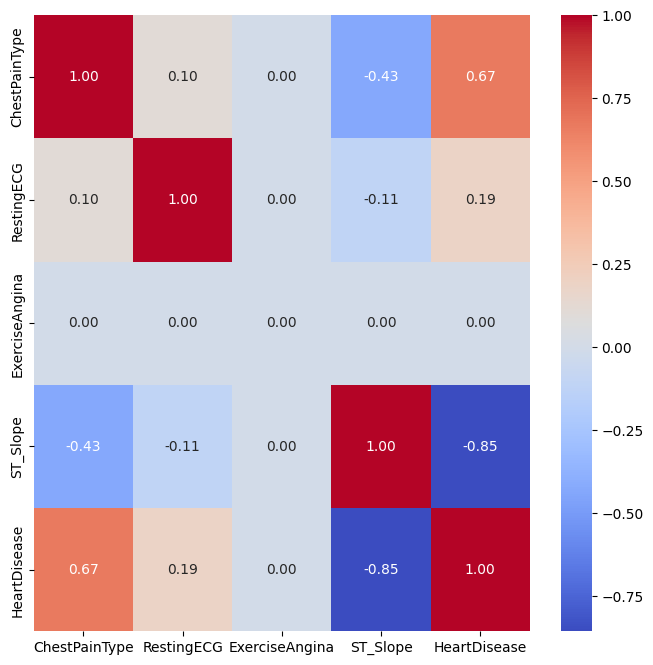

In [373]:
kendall_ordinal = pd.DataFrame(index = fitur_ordinal, columns = fitur_ordinal)

for col1 in fitur_ordinal:
    for col2 in fitur_ordinal:
        kendall_ordinal.loc[col1, col2] = kendall_method(dataset_copy[col1].values, dataset_copy[col2].values)

kendall_ordinal = kendall_ordinal.astype(float) 
plt.figure(figsize = (8, 8))
sns.heatmap(kendall_ordinal, cmap = 'coolwarm', fmt = '.2f', annot = True)
plt.show()

#### *c. Chi-Square Method*

In [374]:
def chi_square_method(data, col1, col2):

    observed = pd.crosstab(data[col1], data[col2])
    totals = observed.values.sum()
    row_totals = observed.sum(axis = 1).values.reshape(-1, 1)
    col_totals = observed.sum(axis = 0).values.reshape(1, -1)

    expected = row_totals @ col_totals / totals
    chi_square = ((observed.values - expected) ** 2 / expected).sum()

    return chi_square

In [375]:
chi_scores = []

for col in fitur_nominal:
    chi = chi_square_method(dataset_copy, col, "HeartDisease")
    chi_scores.append((col, chi))

chi_df = pd.DataFrame(chi_scores, columns = ['Feature', 'Chi Scores'])
chi_df = chi_df.sort_values(by = 'Chi Scores', ascending = False)

C:\Users\ACER\AppData\Local\Temp\ipykernel_7032\4102313991.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(chi_df, x='Feature', y = 'Chi Scores', palette='magma')


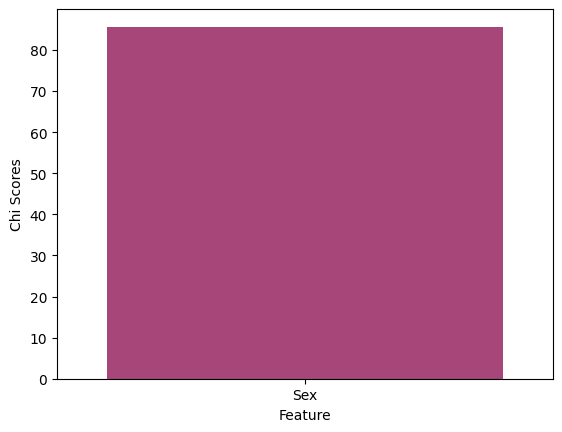

In [376]:
sns.barplot(chi_df, x='Feature', y = 'Chi Scores', palette='magma')
plt.show()

### 11. Data Outlier

#### *a. Inspeksi Rentang Data*

In [377]:
def check_iqr(dataset, col):
    for cols in col:
        Q1 = dataset[cols].quantile(0.25)
        Q3 = dataset[cols].quantile(0.75)

        IQR = Q3 - Q1
        print(f"Kolom {cols}")
        print(f"Q1: {Q1}")
        print(f'Q3: {Q3}')
        print(f'IQR: {IQR}\n')

In [378]:
check_iqr(dataset_copy, fitur_continu)

Kolom RestingBP
Q1: 120.0
Q3: 140.0
IQR: 20.0

Kolom Cholesterol
Q1: 173.25
Q3: 267.0
IQR: 93.75

Kolom FastingBS
Q1: 0.0
Q3: 0.0
IQR: 0.0

Kolom HeartDisease
Q1: 0.0
Q3: 1.0
IQR: 1.0



#### *b. Visualisasi Boxplot*

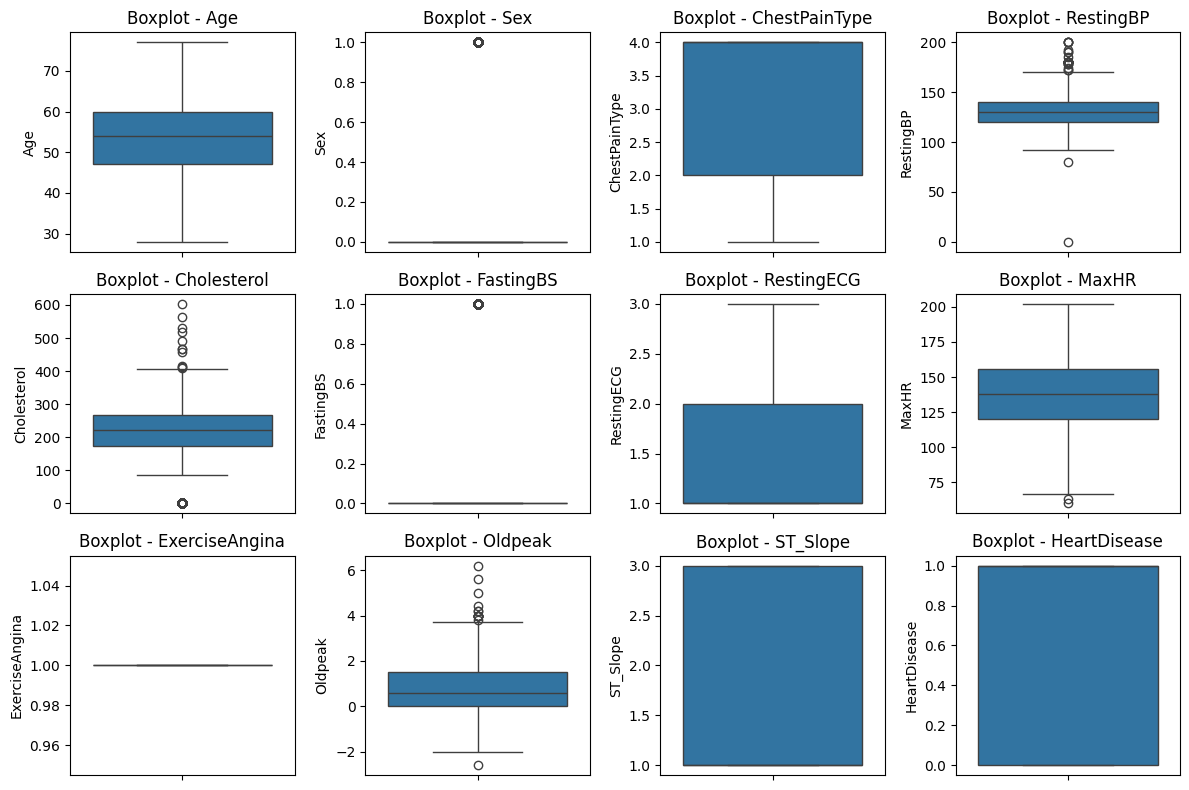

In [379]:
plt.figure(figsize=(12, 8))

for i, col in enumerate(dataset_copy):
    plt.subplot(3, 4, i+1)
    sns.boxplot(y=dataset_copy[col])
    plt.title(f"Boxplot - {col}")

plt.tight_layout()
plt.show()

### 12. Conclusion Analysis

Ada beberapa hal yang bisa kami tarik pada proses EDA antara lain:

1. Fitur yang korelasinya yang hampir sama sama kuat di kedua method pengecekan korelasi adalah Oldpeak, ChestPainType, Age, RestingBS, Sex

2. Di Distribusi fitur terhadap target semakin tinggi oldpeaknya maka semakin besar pula rasio orang yang terkena penyakit jatung ketinmbang tidak. hal yang sama berlaku dengan fitur Age, dan RestingBS

3. Kebanyakan pengidap penyakit jantung itu laki laki ketimbang perempuan

4. ChestPainType yang umum diderita pengidap penyakit jantung adalah tipe ASY

5. Proporsi kelas/target sudah seimbang sehingga tidak diperlukan oversampling maupun undersampling

## ***B. Feature Selection***

Setelah menganalisa fitur mana yang memiliki korelasi terbaik, kami menerapkan beberapa kombinasi fitur.

In [380]:
all_feature_cols = ['Age','Sex','ChestPainType','RestingBP','Cholesterol','FastingBS','RestingECG','MaxHR','ExerciseAngina','Oldpeak','ST_Slope']
top_6_cols = ['Oldpeak', 'ChestPainType', 'Age', 'RestingBP', 'Sex', 'RestingECG']
top_5_cols = ['Oldpeak', 'ChestPainType', 'Age', 'RestingBP', 'Sex']
top_3_cols = ['Age', 'ChestPainType', 'Oldpeak']

## ***C. Data Preprocessing***

In [381]:
dataset= label_encode(dataset, fitur_nominal)
dataset['ChestPainType'] = dataset['ChestPainType'].map(map_chest)
dataset['RestingECG'] = dataset['RestingECG'].map(map_resting)
dataset['ExerciseAngina'] = dataset['ExerciseAngina'].map(map_exercise)
dataset['ST_Slope'] = dataset['ST_Slope'].map(map_slope)

In [382]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    int64  
 2   ChestPainType   918 non-null    int64  
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    int64  
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    int64  
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    int64  
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(11)
memory usage: 86.2 KB


## ***D. Splitting Dataset***

### 1. Stratified Dataset

In [383]:
def stratified_split(dataset, target_column, training_size=0.8, random_state=42, frac=1):
    np.random.seed(random_state)
    train_list, test_list = [], []

    for class_value in dataset[target_column].unique():
        class_data = dataset[dataset[target_column] == class_value]
        class_data = class_data.sample(random_state=random_state, frac=frac)

        split_idx = int(len(class_data) * training_size)
        train_list.append(class_data.iloc[:split_idx])
        test_list.append(class_data.iloc[split_idx:])

    train_set = pd.concat(train_list).reset_index(drop=True)
    test_set = pd.concat(test_list).reset_index(drop=True)
    return train_set, test_set

dataste_training, dataset_testing = stratified_split(dataset, "HeartDisease")

## ***E. Data Sampling***

### 1. Random Oversampling

In [384]:
def random_oversampling(dataset, target_column, additional_size = None):

    classes = dataset[target_column].value_counts()
    resampled_data = [dataset]

    for label, size in classes.items:
        if additional_size and additional_size.get(label, 0):
            additional_data = dataset[dataset[label] == label]
            minority_class_data = additional_data.sample(n = additional_size[label], random_state = 42)
            resampled_data.append(minority_class_data)

    final_dataset = pd.concat(resampled_data).sample(random_state=42, replace=True).reset_index(drop=True)
    return final_dataset

## ***F. Feature Target Declaration***

In [385]:
X_train = dataste_training[top_6_cols]
X_test = dataset_testing[top_6_cols]

y_train = dataste_training["HeartDisease"]
y_test = dataset_testing["HeartDisease"]

## ***G. Dimension Reduction***

### 1. Principal Component Analysis

In [386]:
def to_float(dataset, col):
    for cols in col:
        dataset[cols] = dataset[cols].astype(float)
    return dataset

dataset = to_float(dataset, fitur_continu)
dataset = to_float(dataset, fitur_diskrit)

In [387]:
def pca_fit(X, n_components):
    if X.ndim == 1:
        X = X.reshape(-1, 1)

    X_mean = np.mean(X, axis=0)
    X_std = np.std(X, axis=0)
    X_scaled = (X - X_mean) / X_std

    cov = np.cov(X_scaled, rowvar=False)

    if np.ndim(cov) == 0:
        cov = np.array([[cov]])

    eigenvalues, eigenvectors = np.linalg.eigh(cov)

    sorted_indices = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[sorted_indices]
    eigenvectors = eigenvectors[:, sorted_indices]

    components = eigenvectors[:, :n_components]
    X_pca = np.dot(X_scaled, components)
    explained_variance = eigenvalues[:n_components]
    return X_pca, components, X_mean, X_std, explained_variance

def pca_transform(X, components, X_mean, X_std):
    X_scaled = (X - X_mean) / X_std
    return np.dot(X_scaled, components)

### 2. Multiple Correspondence Analysis

In [388]:
def mca_fit(X_cat, n_components):
    X_dummies = pd.get_dummies(X_cat)
    X_matrix = X_dummies.to_numpy()

    row_sums = X_matrix.sum(axis=1, keepdims=True)
    col_sums = X_matrix.sum(axis=0, keepdims=True)
    total = X_matrix.sum()

    expected = row_sums @ col_sums / total
    Z = (X_matrix - expected) / np.sqrt(expected)

    U, S, VT = np.linalg.svd(Z, full_matrices=False)
    X_mca = U[:, :n_components] * S[:n_components]
    components = VT[:n_components, :]
    return X_mca, components, X_dummies.columns

def mca_transform(X_cat, components, dummy_columns):
    X_dummies = pd.get_dummies(X_cat)
    X_dummies = X_dummies.reindex(columns=dummy_columns, fill_value=0)

    X_matrix = X_dummies.to_numpy()
    row_sums = X_matrix.sum(axis=1, keepdims=True)
    col_sums = X_matrix.sum(axis=0, keepdims=True)
    total = X_matrix.sum()
    expected = row_sums @ col_sums / total
    Z = (X_matrix - expected) / np.sqrt(expected)

    X_proj = Z @ components.T
    return X_proj

### 3. Factor Analysis of Mixed Data 

In [391]:
def famd_fit(df, n_components):

    float_cols = df.select_dtypes(include = ['float']).columns
    int_cols = df.select_dtypes(include = ['int']).columns

    X_num = df[float_cols].to_numpy()
    X_pca, pca_components, pca_mean, pca_std, _ = pca_fit(X_num, X_num.shape[1])

    X_cat = df[int_cols]
    X_mca, mca_components, dummy_columns = mca_fit(X_cat, min(n_components, 50))

    X_combined = np.hstack([X_pca, X_mca])
    X_combined_mean = np.mean(X_combined, axis=0)
    X_combined_std = np.std(X_combined, axis=0)
    X_famd, famd_components, _, _, _ = pca_fit(X_combined, n_components)

    return {
        'float_cols' : float_cols,
        'int_cols' : int_cols,
        'X_num' : X_num,
        'X_pca' : X_pca,
        'pca_components' : pca_components,
        'pca_mean' : pca_mean,
        'pca_std' : pca_std,
        'X_mca' : X_mca,
        'mca_components' : mca_components,
        'dummy_columns' : dummy_columns,
        'X_famd' : X_famd,
        'famd_components' : famd_components,
        'X_combined_mean' : X_combined_mean,
        'X_combined_std' : X_combined_std
    }

def famd_transform(df, model):
    
    X_num = df[model['float_cols']].to_numpy()
    safe_std = np.where(model['pca_std'] == 0, 1, model['pca_std'])
    X_scaled = (X_num - model['pca_mean']) / safe_std
    X_pca = np.dot(X_scaled, model['pca_components'])

    X_cat = df[model['int_cols']]
    X_mca = mca_transform(X_cat, model['mca_components'], model['dummy_columns'])

    X_combined = np.hstack([X_pca, X_mca])
    safe_std_combined = np.where(model['X_combined_std'] == 0, 1, model['X_combined_std'])
    X_combined_scaled = (X_combined - model['X_combined_mean']) / safe_std_combined
    X_famd = np.dot(X_combined_scaled, model['famd_components'])

    return X_famd

In [392]:
famd_model = famd_fit(X_train, n_components= 2)
X_train_famd = famd_model['X_famd']
X_test_famd = famd_transform(X_test, famd_model)

famd_df = pd.DataFrame(X_train_famd, columns=['Dim 1', 'Dim 2'])
famd_df['target'] = y_train.values

In [393]:
X_test_famd

array([[ 0.15852367,  0.54712412],
       [ 0.41795595,  1.57190981],
       [ 0.83699451, -0.86805072],
       [ 0.32010344,  0.67694837],
       [ 2.41449758, -0.05949319],
       [ 0.06732104, -0.05717374],
       [ 1.41558585, -1.47434025],
       [ 0.89347746, -1.86940332],
       [-1.33704341, -0.53778253],
       [ 1.72844389, -0.57376271],
       [ 2.14532202, -0.37235583],
       [ 0.64803625,  0.32333958],
       [-2.18060656, -1.34794485],
       [ 0.67130647,  0.71015297],
       [-0.00965851,  0.27953529],
       [ 0.51956753, -0.03846249],
       [ 0.20267557, -0.24333667],
       [ 0.94660492,  1.37158132],
       [ 1.11837793,  1.1336142 ],
       [ 2.40443468,  0.19295951],
       [-0.72341933,  0.55085868],
       [ 0.87896439,  1.04320704],
       [ 1.22833346, -1.57322326],
       [ 1.77867332, -0.87107045],
       [ 1.58430382, -0.20411788],
       [ 0.11432019, -0.76308288],
       [ 0.92981442, -1.1891563 ],
       [ 0.67132035, -3.34866957],
       [-0.72615141,

### 4. Visualisasi Data Training

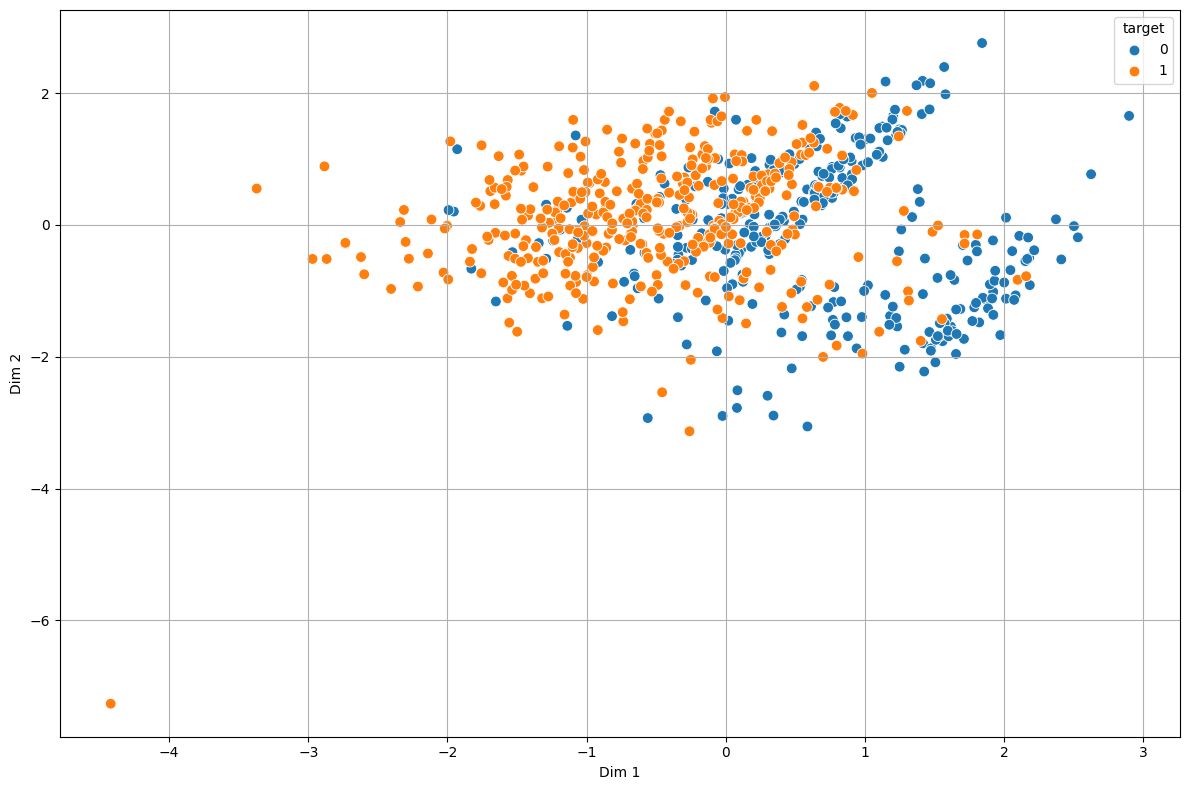

In [394]:
plt.figure(figsize=(12, 8))
sns.scatterplot(famd_df, x='Dim 1', y = 'Dim 2', s = 60, hue='target', palette='tab10')
plt.grid(True)
plt.tight_layout()
plt.show()

# **III. Modeling**

## ***A. Model Application***

### 1. Model dengan Class

In [395]:
class KNN:
    def __init__(self, k=5, p=2):
        self.k = k
        self.p = p

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def minkowski_distance(self, a, b):
        return np.sum(np.abs(a - b) ** self.p) ** (1 / self.p)
    
    def predict(self, X):
        X_test = X
        distances = np.zeros((X_test.shape[0], self.X_train.shape[0]))

        for i, test_point in enumerate(X_test):
            for j, train_point in enumerate(self.X_train):
                distances[i, j] = self.minkowski_distance(test_point, train_point)

        nearest_neighhbor_indices = np.argsort(distances, axis=1)[:, :self.k]
        neighbors = np.array(self.y_train)[nearest_neighhbor_indices]

        y_pred = []
        for neighbor_classes in neighbors:
            classes, counts = np.unique(neighbor_classes, return_counts=True)
            predicted_classes = classes[np.argmax(counts)]
            y_pred.append(predicted_classes)

        return np.array(y_pred)
    
    def plot_neighbors(self, input_point, y_train, zoom=False):
        distances = np.array([self.minkowski_distance(input_point, train_point) for train_point in self.X_train])
        nearest_neighbors_indices = np.argsort(distances)[:self.k]

        plt.figure(figsize=(12, 8))
        scatter = plt.scatter(self.X_train[:, 0], self.X_train[:, 1], c=y_train, cmap="coolwarm", alpha=0.7, label="Training Data")
        plt.colorbar(scatter, label="Classes")

        plt.scatter(input_point[0], input_point[1], c="yellow", edgecolors="black", s=200, marker="*", label="Input Data")

        if zoom:
            all_x = [input_point[0]] + [self.X_train[idx][0] for idx in nearest_neighbors_indices]
            all_y = [input_point[1]] + [self.X_train[idx][1] for idx in nearest_neighbors_indices]

            x_padding = (max(all_x) - min(all_x)) * 0.2
            y_padding = (max(all_y) - min(all_y)) * 0.2

            offset_y = y_padding * 0.15

            plt.xlim(min(all_x) - x_padding, max(all_x) + x_padding)
            plt.ylim(min(all_y) - y_padding, max(all_y) + y_padding)

            print("Nearest Neighbor Label:")
            for i, idx in enumerate(nearest_neighbors_indices):
                print(f"Nearest Neighbor {i+1}: Label - {y_train[idx]}")

        else:
            offset_y = 0.2

        cmap = plt.cm.coolwarm
        norm = plt.Normalize(vmin=0, vmax=0)

        for i, idx in enumerate(nearest_neighbors_indices):
            neighbor_point = self.X_train[idx]
            color = cmap(norm(y_train[idx]))
            label = "Nearest Neighbors" if i == 0 else None
            plt.scatter(neighbor_point[0], neighbor_point[1], facecolors=color, edgecolors="black", s=75, linewidths=2, label=label)
            plt.plot([input_point[0], neighbor_point[0]], [input_point[1], neighbor_point[1]], "black", linestyle="dashed", alpha=0.5)
            plt.text(neighbor_point[0], neighbor_point[1] + offset_y, f"{i+1}", fontsize=9, color="black", ha="center")

        plt.xlabel("Dimensi 1 FAMD")
        plt.ylabel("Dimensi 2 FAMD")
        plt.title("FAMD Scatter Plot dengan Input Data Baru")
        plt.legend()
        plt.show()

### 2. Rule of Thumb

In [396]:
rule_of_thumb = round(np.sqrt(len(X_train_famd)))
rule_of_thumb

27

### 3. K Cross Validation

#### *a. Manhattan Distance*

In [397]:
k_valid = range(1, 11)
train_accs = []
test_accs = []

for k in k_valid:
    model = KNN(k=k, p=1)
    model.fit(X_train_famd, y_train)
    y_pred_train = model.predict(X_train_famd)
    y_pred_test = model.predict(X_test_famd)

    train_acc = np.mean(y_pred_train == y_train) * 100
    test_acc = np.mean(y_pred_test == y_test) * 100

    train_accs.append(train_acc)
    test_accs.append(test_acc)

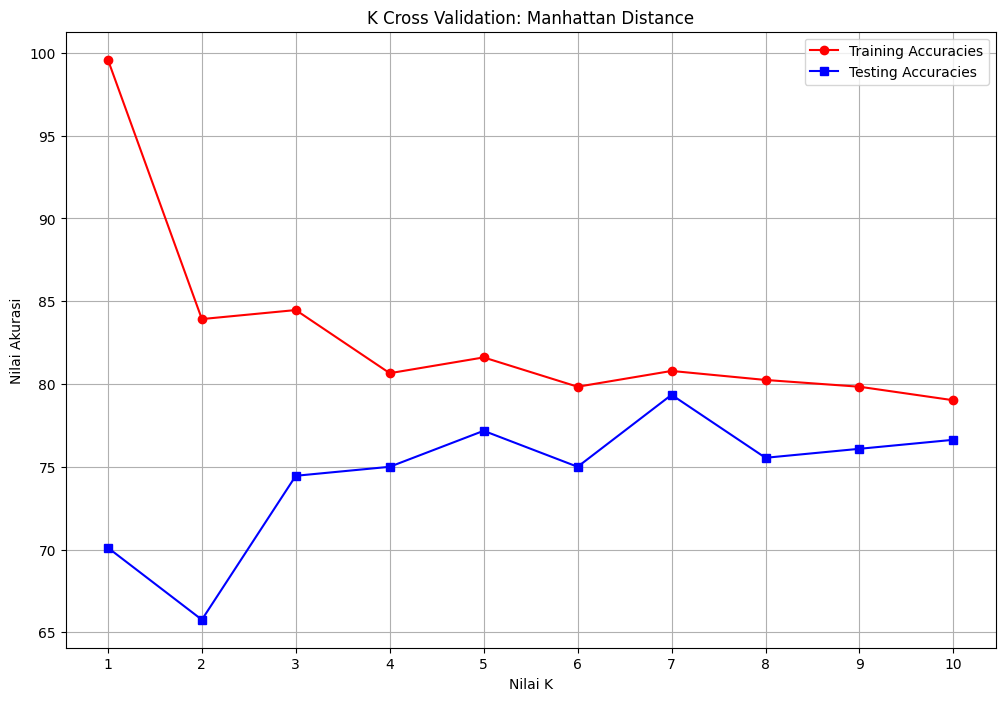

In [398]:
plt.figure(figsize=(12, 8))
plt.plot(k_valid, train_accs, marker="o", label="Training Accuracies", color="red")
plt.plot(k_valid, test_accs, marker="s", label="Testing Accuracies", color="blue")
plt.xlabel("Nilai K")
plt.ylabel("Nilai Akurasi")
plt.title("K Cross Validation: Manhattan Distance")
plt.xticks(k_valid)
plt.legend()
plt.grid()
plt.show()

#### *b. Euclidean Distance*

In [399]:
train_accs = []
test_accs = []

for k in k_valid:
    model = KNN(k=k, p=2)
    model.fit(X_train_famd, y_train)
    y_pred_train = model.predict(X_train_famd)
    y_pred_test = model.predict(X_test_famd)

    train_acc = np.mean(y_pred_train == y_train) * 100
    test_acc = np.mean(y_pred_test == y_test) * 100

    train_accs.append(train_acc)
    test_accs.append(test_acc)

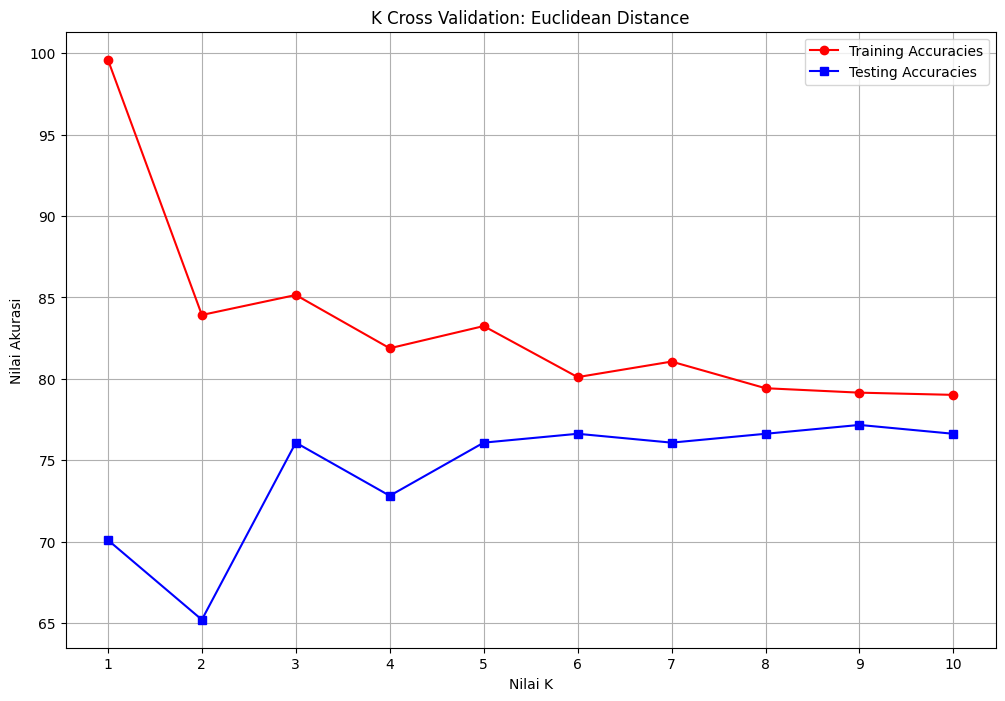

In [400]:
plt.figure(figsize=(12, 8))
plt.plot(k_valid, train_accs, marker="o", label="Training Accuracies", color="red")
plt.plot(k_valid, test_accs, marker="s", label="Testing Accuracies", color="blue")
plt.xlabel("Nilai K")
plt.ylabel("Nilai Akurasi")
plt.title("K Cross Validation: Euclidean Distance")
plt.xticks(k_valid)
plt.legend()
plt.grid()
plt.show()

### 4. Elbow Method

In [401]:
def error_rate(y_true, y_pred):
    return np.sum(y_true != y_pred) / len(y_true)

#### *a. Manhattan Distance*

In [402]:
k_elbow = range(6, 11)
errors = []

for k in k_elbow:
    model = KNN(k=k, p=1)
    model.fit(X_train_famd, y_train)
    y_pred_test = model.predict(X_test_famd)

    error = error_rate(y_test, y_pred_test)
    errors.append(error)

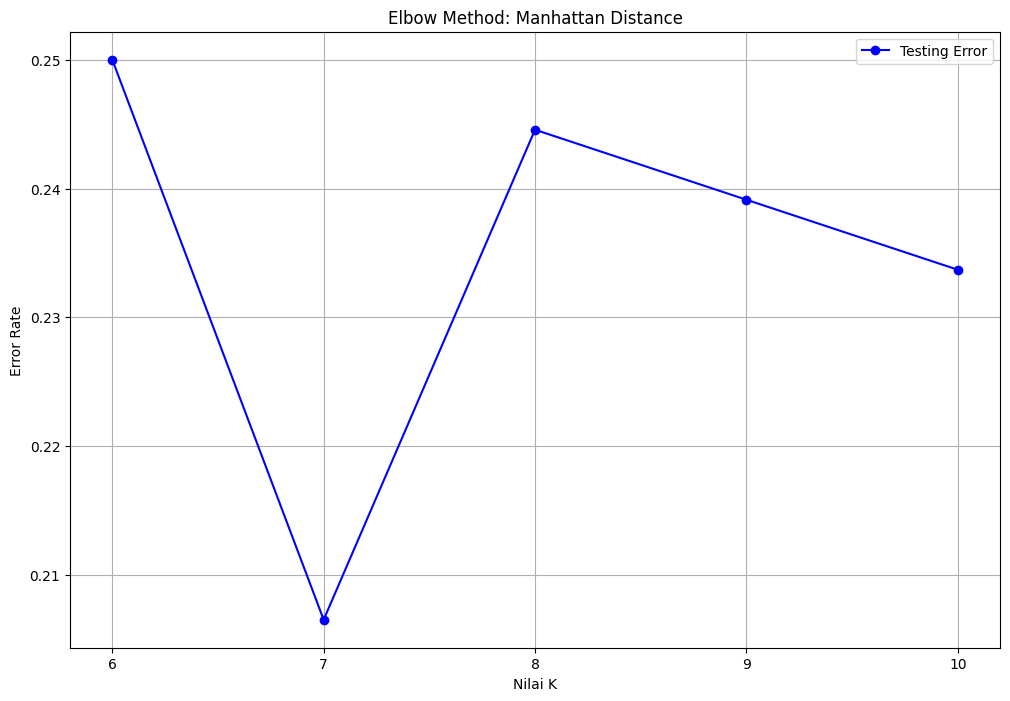

In [403]:
plt.figure(figsize=(12, 8))
plt.plot(k_elbow, errors, marker="o", label="Testing Error", color="blue")
plt.xlabel("Nilai K")
plt.ylabel("Error Rate")
plt.title("Elbow Method: Manhattan Distance")
plt.xticks(k_elbow)
plt.legend()
plt.grid()
plt.show()

#### *b. Euclidean Distance*

In [404]:
errors = []

for k in k_elbow:
    model = KNN(k=k, p=2)
    model.fit(X_train_famd, y_train)
    y_pred_test = model.predict(X_test_famd)

    error = error_rate(y_test, y_pred_test)
    errors.append(error)

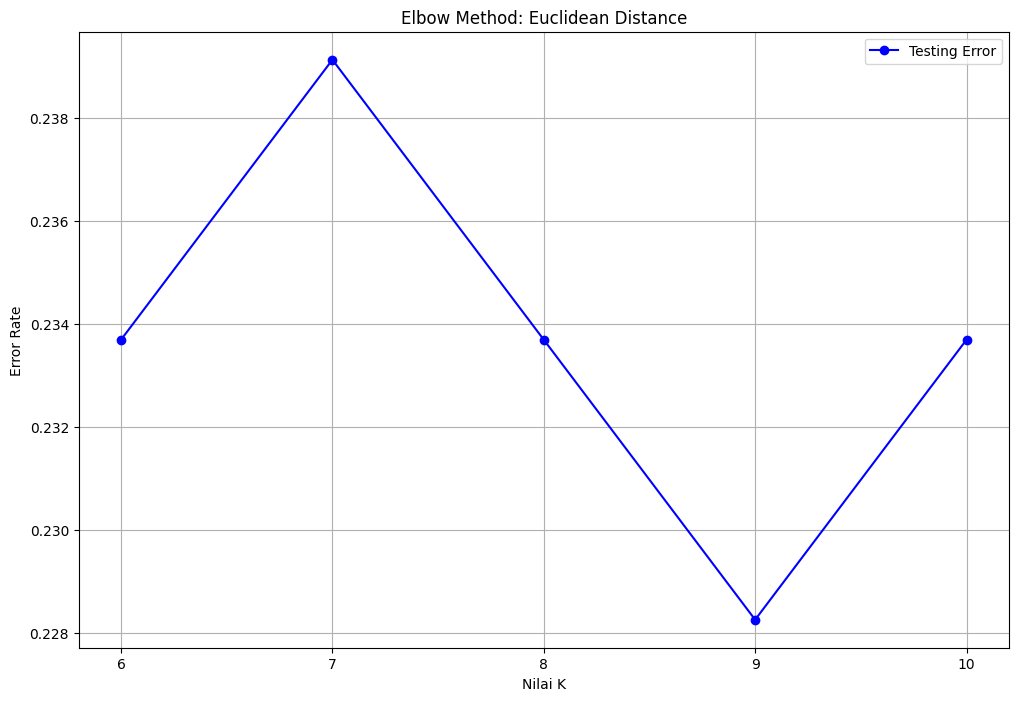

In [405]:
plt.figure(figsize=(12, 8))
plt.plot(k_elbow, errors, marker="o", label="Testing Error", color="blue")
plt.xlabel("Nilai K")
plt.ylabel("Error Rate")
plt.title("Elbow Method: Euclidean Distance")
plt.xticks(k_elbow)
plt.legend()
plt.grid()
plt.show()

### 5. Pengaplikasian Model

#### *a. Manhattan Distance*

In [406]:
model1 = KNN(k=7, p=1)
model1.fit(X_train_famd, y_train)
y_pred_train1 = model1.predict(X_train_famd)
y_pred_test1 = model1.predict(X_test_famd)

#### *b. Euclidean Distance*

In [407]:
model2 = KNN(k=7, p=2)
model2.fit(X_train_famd, y_train)
y_pred_train2 = model2.predict(X_train_famd)
y_pred_test2 = model2.predict(X_test_famd)

## ***B. Visualisasi Model***

### 1. Uji Coba Data Baru

In [408]:
top_6_cols

['Oldpeak', 'ChestPainType', 'Age', 'RestingBP', 'Sex', 'RestingECG']

**Data Baru**:
1. Oldpeak: 2.7
2. ChestPainType: NAP
3. Age: 33
4. RestingBP: 175
5. Sex: M
6. RestingECG: ST

**Encoding Feature**:
1. `ChestPainType` = {'ASY' : 4, 'NAP' : 1, 'ATA' : 2, 'TA' : 3}
2. `RestingECG` = {'Normal' : 1, 'LVH' : 2, 'ST' : 3}

In [409]:
input_data = [2.7, 1, 33, 175, 0, 3]
input_df = pd.DataFrame([input_data], columns=top_6_cols)
input_df[['Age', "RestingBP"]] = input_df[['Age', "RestingBP"]].astype(float)

In [410]:
input_famd = famd_transform(input_df, famd_model)[0]

C:\Users\ACER\AppData\Local\Temp\ipykernel_7032\3722470100.py:26: RuntimeWarning: invalid value encountered in divide
  Z = (X_matrix - expected) / np.sqrt(expected)


In [411]:
input_df

,Oldpeak,ChestPainType,Age,RestingBP,Sex,RestingECG
0,2.7,1,33.0,175.0,0,3


In [412]:
input_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Oldpeak        1 non-null      float64
 1   ChestPainType  1 non-null      int64  
 2   Age            1 non-null      float64
 3   RestingBP      1 non-null      float64
 4   Sex            1 non-null      int64  
 5   RestingECG     1 non-null      int64  
dtypes: float64(3), int64(3)
memory usage: 180.0 bytes


In [413]:
input_famd

array([nan, nan])

### 2. Distribusi Hasil Prediksi

#### *a. Manhattan Distance*

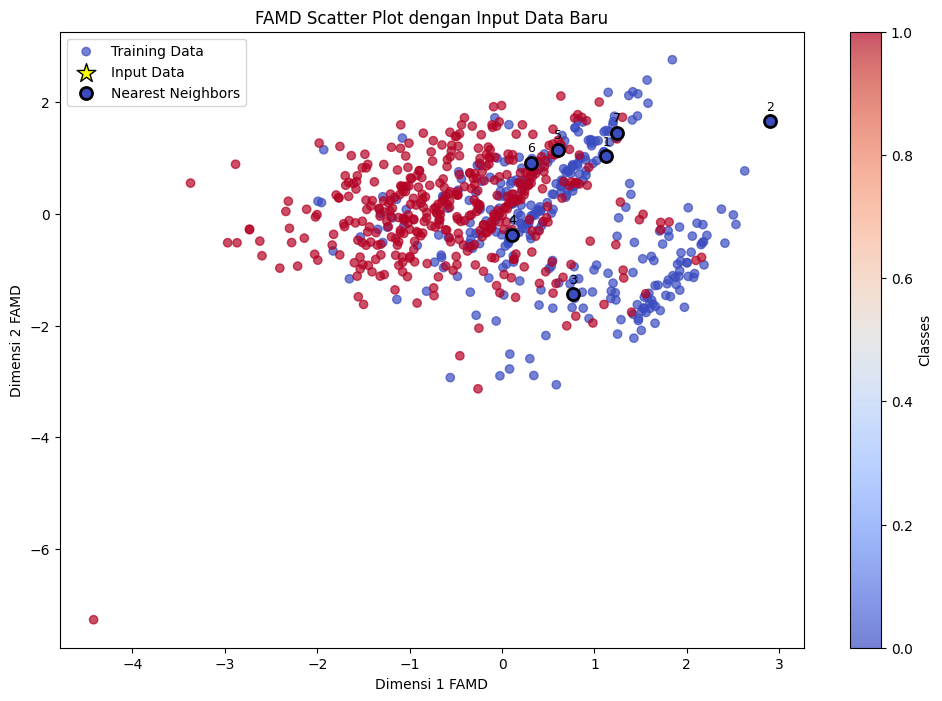

In [414]:
model1.plot_neighbors(input_famd, y_train, zoom=False)

ValueError: Axis limits cannot be NaN or Inf

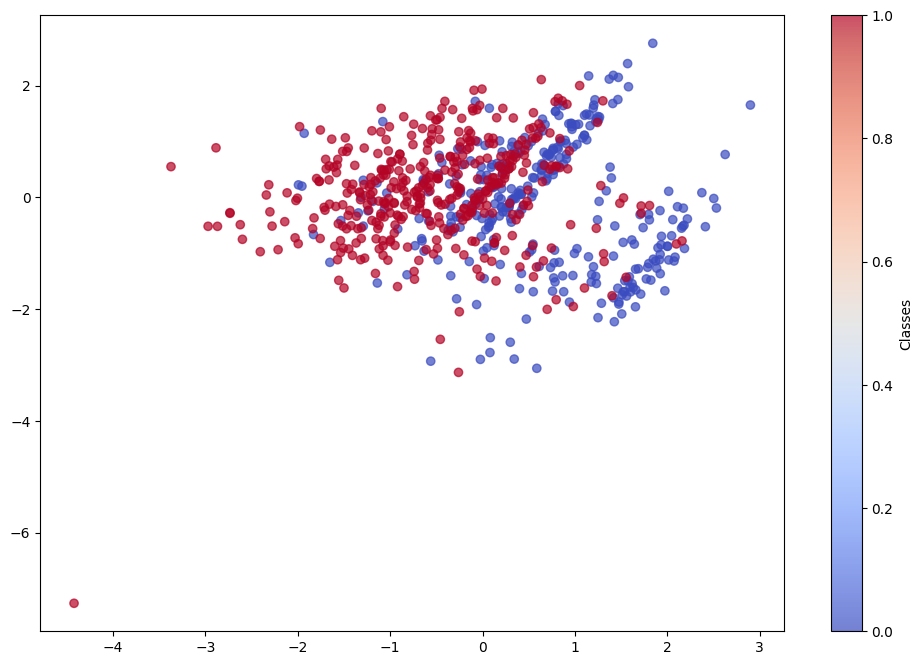

In [415]:
model1.plot_neighbors(input_famd, y_train, zoom=True)

#### *b. Euclidean Distance*

In [ ]:
model2.plot_neighbors(input_famd, y_train, zoom=False)

In [ ]:
model2.plot_neighbors(input_famd, y_train, zoom=True)

### 3. Confusion Matrix

### 4. Reverse Mapping

### 5. Analisis Hubungan Antar Fitur

#### *a. Fitur Numerik*

#### *b. Fitur Kategorikal*

## ***C. Evaluasi Model***

### 1. Confusion Matrix

#### *a. Fungsi Confusion Matrix*

#### *b. Evaluasi Model Manhattan*

#### *c. Evaluasi Model Euclidean*

### 2. Bias dan Variance Model

### 3. K-Fold Cross Validation

#### *a. Fungsi K-Fold*

#### *b. Model K-Fold*

# **IV. Final Evaluation**

---
Copyright @ 2025. Asta Production. All rights reserved.